In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mksaad/arabic-sentiment-twitter-corpus")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'arabic-sentiment-twitter-corpus' dataset.
Path to dataset files: /kaggle/input/arabic-sentiment-twitter-corpus


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
tqdm.pandas()
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import os

In [4]:
train_pos_df = pd.read_csv('/kaggle/input/arabic-sentiment-twitter-corpus/train_Arabic_tweets_positive_20190413.tsv', sep='\t', header=None)
train_neg_df = pd.read_csv('/kaggle/input/arabic-sentiment-twitter-corpus/train_Arabic_tweets_negative_20190413.tsv', sep='\t', header=None)
test_pos_df = pd.read_csv('/kaggle/input/arabic-sentiment-twitter-corpus/test_Arabic_tweets_positive_20190413.tsv', sep='\t', header=None)
test_neg_df = pd.read_csv('/kaggle/input/arabic-sentiment-twitter-corpus/test_Arabic_tweets_negative_20190413.tsv', sep='\t', header=None)

In [5]:
train_df = pd.concat([train_pos_df, train_neg_df], ignore_index=True)
test_df = pd.concat([test_pos_df, test_neg_df], ignore_index=True)

In [6]:
for df in [train_df, test_df]:
    df.columns = ['label', 'tweet']


In [7]:
train_df.shape

(45275, 2)

<Axes: xlabel='label', ylabel='count'>

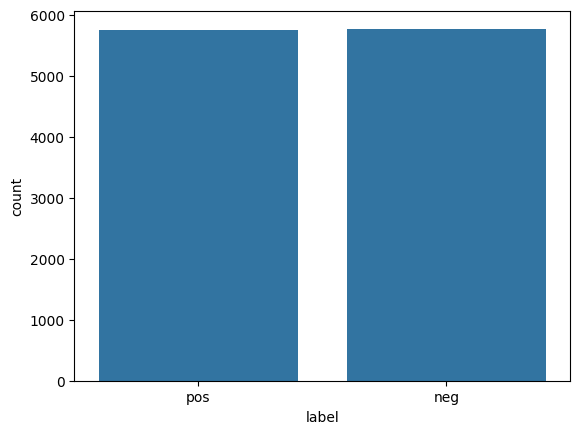

In [9]:
sns.countplot(data=df,x='label')

In [10]:
def remove_html_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub('', text)

In [11]:
df['tweet']=df['tweet'].progress_apply(lambda x : remove_html_tags(x))
df.head()

100%|██████████| 11520/11520 [00:00<00:00, 597962.78it/s]


,label,tweet
0,pos,#الهلال_الاهلي فوز هلالي مهم الحمد لله 💙 زوران...
1,pos,صباحك خيرات ومسرات 🌸
2,pos,#تأمل قال الله ﷻ :- _*​﴿بواد غير ذي زرع ﴾*_ 💫💫...
3,pos,😂😂 يا جدعان الرجاله اللي فوق ال دول خطر ع تويت...
4,pos,رساله صباحيه : 💛 اللهم اسألك التوفيق في جميع ا...


In [12]:
def remove_url(text):
    pattern=re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'',text)

df['tweet']=df['tweet'].progress_apply(lambda x : remove_url(x))
df.head()

100%|██████████| 11520/11520 [00:00<00:00, 437757.70it/s]


,label,tweet
0,pos,#الهلال_الاهلي فوز هلالي مهم الحمد لله 💙 زوران...
1,pos,صباحك خيرات ومسرات 🌸
2,pos,#تأمل قال الله ﷻ :- _*​﴿بواد غير ذي زرع ﴾*_ 💫💫...
3,pos,😂😂 يا جدعان الرجاله اللي فوق ال دول خطر ع تويت...
4,pos,رساله صباحيه : 💛 اللهم اسألك التوفيق في جميع ا...


In [14]:
import emoji

df['tweet'] = df['tweet'].progress_apply(emoji.demojize)
df.head()

100%|██████████| 11520/11520 [00:01<00:00, 8291.54it/s]


,label,tweet
0,pos,#الهلال_الاهلي فوز هلالي مهم الحمد لله :blue_h...
1,pos,صباحك خيرات ومسرات :cherry_blossom:
2,pos,#تأمل قال الله ﷻ :- _*​﴿بواد غير ذي زرع ﴾*_ :d...
3,pos,:face_with_tears_of_joy::face_with_tears_of_jo...
4,pos,رساله صباحيه : :yellow_heart: اللهم اسألك التو...


In [16]:
# remove digits
def remove_digits(text):
    return re.sub(r'\d+', '', text)

df['tweet'] = df['tweet'].progress_apply(lambda x: remove_digits(x))
df.head()

100%|██████████| 11520/11520 [00:00<00:00, 145759.01it/s]


,label,tweet
0,pos,#الهلال_الاهلي فوز هلالي مهم الحمد لله :blue_h...
1,pos,صباحك خيرات ومسرات :cherry_blossom:
2,pos,#تأمل قال الله ﷻ :- _*​﴿بواد غير ذي زرع ﴾*_ :d...
3,pos,:face_with_tears_of_joy::face_with_tears_of_jo...
4,pos,رساله صباحيه : :yellow_heart: اللهم اسألك التو...


In [17]:
import string
exclude=string.punctuation
exclude

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [18]:
def remove_punc(text):
    for char in exclude:
        text=text.replace(char,'')
    return text

df['tweet']=df['tweet'].progress_apply(lambda x : remove_punc(x))
df.head()

100%|██████████| 11520/11520 [00:00<00:00, 36504.86it/s]


,label,tweet
0,pos,الهلالالاهلي فوز هلالي مهم الحمد لله blueheart...
1,pos,صباحك خيرات ومسرات cherryblossom
2,pos,تأمل قال الله ﷻ ​﴿بواد غير ذي زرع ﴾ dizzydizz...
3,pos,facewithtearsofjoyfacewithtearsofjoy يا جدعان ...
4,pos,رساله صباحيه yellowheart اللهم اسألك التوفيق ...


In [19]:
from nltk.corpus import stopwords

In [20]:
import nltk
nltk.download('stopwords')
arabic_StopWords = stopwords.words("arabic")
english_StopWords = stopwords.words("english")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [21]:
def remove_stopwords(text):
    return " ".join([
        word for word in text.split()
        if word.lower() not in arabic_StopWords and word.lower() not in english_StopWords
    ])

df['tweet']=df['tweet'].progress_apply(lambda x : remove_stopwords(x))
df.head()

100%|██████████| 11520/11520 [00:02<00:00, 5650.01it/s]


,label,tweet
0,pos,الهلالالاهلي فوز هلالي مهم الحمد لله blueheart...
1,pos,صباحك خيرات ومسرات cherryblossom
2,pos,تأمل قال الله ﷻ ​﴿بواد زرع ﴾ dizzydizzy writin...
3,pos,facewithtearsofjoyfacewithtearsofjoy جدعان الر...
4,pos,رساله صباحيه yellowheart اللهم اسألك التوفيق ا...


In [22]:
X_train = train_df['tweet']
y_train = train_df['label']
X_test = test_df['tweet']
y_test = test_df['label']

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

In [25]:
tfidf_unigram = TfidfVectorizer(
    lowercase=True,
    tokenizer=None,
    stop_words=None,
    ngram_range=(1, 1),  # (1,1)
    max_features=None,
    vocabulary=None,
    binary=False
)

X_train_tfidf_unigram = tfidf_unigram.fit_transform(X_train)
X_test_tfidf_unigram = tfidf_unigram.transform(X_test)

In [ ]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Linear SVM": LinearSVC(),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier()
}

In [29]:
import pandas as pd

results = []

vectorizers = {
    "TF-IDF N-gram (1,1)": (X_train_tfidf_unigram, X_test_tfidf_unigram)
}

for vec_name, (Xtr, Xte) in vectorizers.items():
    for model_name, model in models.items():
        model.fit(Xtr, y_train)
        preds = model.predict(Xte)
        acc = accuracy_score(y_test, preds)

        results.append({
            "Vectorizer": vec_name,
            "Model": model_name,
            "Accuracy": round(acc, 4)
        })

df_results = pd.DataFrame(results)
print(df_results)


            Vectorizer                Model  Accuracy
0  TF-IDF N-gram (1,1)  Logistic Regression    0.7802
1  TF-IDF N-gram (1,1)           Linear SVM    0.7834
2  TF-IDF N-gram (1,1)          Naive Bayes    0.7804
3  TF-IDF N-gram (1,1)        Random Forest    0.7713
